In [ ]:
# ============================================================
# How to run this notebook
# ============================================================
# This notebook is designed to run on Google Colab.
# No local setup is required.
#
# 1. Click "Runtime -> Run all"
# 2. Wait for the pipeline to complete.
# 3. All experiments use a fixed random_state=42,
#    so re-running the notebook reproduces the reported results.
#
# The dataset is fetched automatically from the UCI repository
# via the `ucimlrepo` package, so no manual download is required.
# ============================================================

# Project 1 - Supervised Learning


Dataset available at https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset

## Phase 1 - Data loading and exploratory analysis

### Imports and dataset loading
We load the Online Shoppers Purchasing Intention dataset (UCI id=468) via the
`ucimlrepo` package and inspect its structure before any preprocessing.

In [ ]:
# Install the UCI ML repository client (needed only once per runtime)
!pip install ucimlrepo

In [ ]:
# Load the dataset as two dataframes (features and target) and concatenate
# them into a single df for exploratory analysis
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np


# fetch dataset
online_shoppers_purchasing_intention_dataset = fetch_ucirepo(id=468)

# data (as pandas dataframes)
X = online_shoppers_purchasing_intention_dataset.data.features
y = online_shoppers_purchasing_intention_dataset.data.targets
frames = [X, y]

df = pd.concat(frames, axis=1)

# metadata
print(online_shoppers_purchasing_intention_dataset.metadata)

# variable information
print(online_shoppers_purchasing_intention_dataset.variables)


{'uci_id': 468, 'name': 'Online Shoppers Purchasing Intention Dataset', 'repository_url': 'https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset', 'data_url': 'https://archive.ics.uci.edu/static/public/468/data.csv', 'abstract': 'Of the 12,330 sessions in the dataset,\n84.5% (10,422) were negative class samples that did not\nend with shopping, and the rest (1908) were positive class\nsamples ending with shopping.', 'area': 'Business', 'tasks': ['Classification', 'Clustering'], 'characteristics': ['Multivariate'], 'num_instances': 12330, 'num_features': 17, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['Revenue'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2018, 'last_updated': 'Thu Jan 11 2024', 'dataset_doi': '10.24432/C5F88Q', 'creators': ['C. Sakar', 'Yomi Kastro'], 'intro_paper': {'ID': 367, 'type': 'NATIVE', 'title': 'Real-time prediction of online shoppers’ pur

In [ ]:
# Basic structural inspection: first rows
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [ ]:
# Basic structural inspection: shape
df.shape

(12330, 18)

In [ ]:
# Basic structural inspection: column names
df.columns

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='object')

In [ ]:
# Basic structural inspection: dtypes
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [ ]:
# Basic structural inspection: summary statistics
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [ ]:
# Basic structural inspection: class distribution of the target
display(df['Revenue'].value_counts())
val = df['Revenue'].sum()
print(val / len(df['Revenue']) * 100, "%")

,count
Revenue,
False,10422
True,1908


15.474452554744525 %


### Correlation analysis
Pearson correlation matrix on numerical features, computed before encoding so
that the values remain interpretable. We use it to detect highly correlated
pairs that could introduce multicollinearity in the models.


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

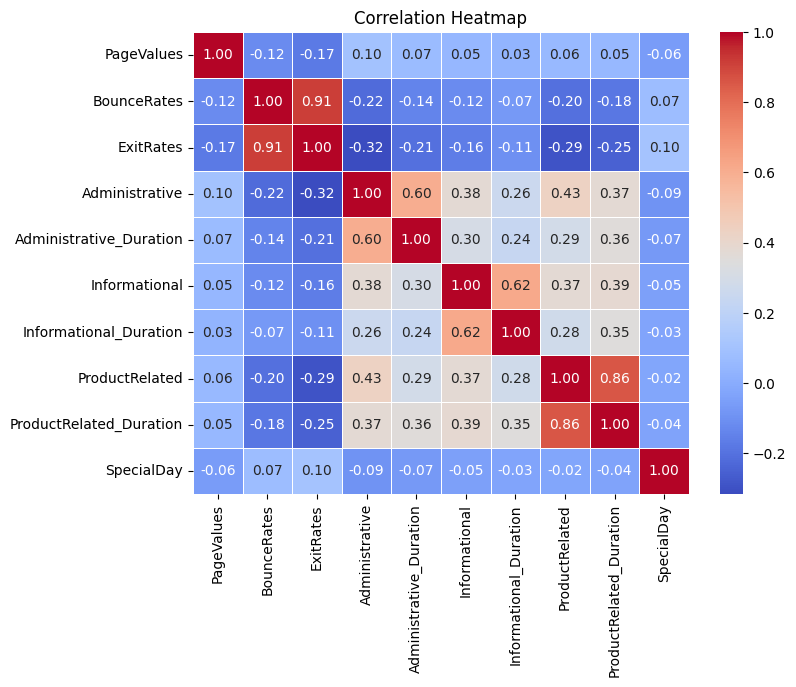

In [ ]:
# Pearson correlation among numerical features (categorical ones are excluded
# because they are not numeric yet). We annotate the cells for readability
categorical_values = ['Month','VisitorType', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Weekend']
numerical_values = ['PageValues', 'BounceRates', 'ExitRates', 'Administrative','Administrative_Duration','Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'SpecialDay']

matrix = df[numerical_values].corr()
plt.figure(figsize=(8,6))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()


The correlation matrix highlights two key pieces of information regarding the correlation between features:

*   ExitRates and BounceRates have a correlation coefficient of 0.91
*   ProductRelated and ProductRelated_Duration have a correlation coefficient of 0.86.

These values allow us to identify the interdependence of the features, analyzed based on their meanings:


*   **BounceRates:** Average bounce rate of the pages visited by the visitor (the frequency with which pages were closed without any interaction).
*   **ExitRates:** Average exit rate of the pages visited by the visitor (frequency of pages closed).

From this view of the domain, we can conclude that the number of pages closed without interaction (bounce rates) is directly dependent on the number of pages closed (exit rates).

Since bounce rates are a subset of exit rates, let's consider empirically excluding the more specific category (bounce rates).

### Outlier analysis
Duration features are heavily right-skewed: some sessions last much longer than
the third quartile. We apply the IQR rule (with a 2.5×IQR threshold, more
conservative than the standard 1.5×IQR) to quantify how many rows would be
flagged as outliers, and we check the purchase rate among those rows before
deciding whether to keep or remove them.


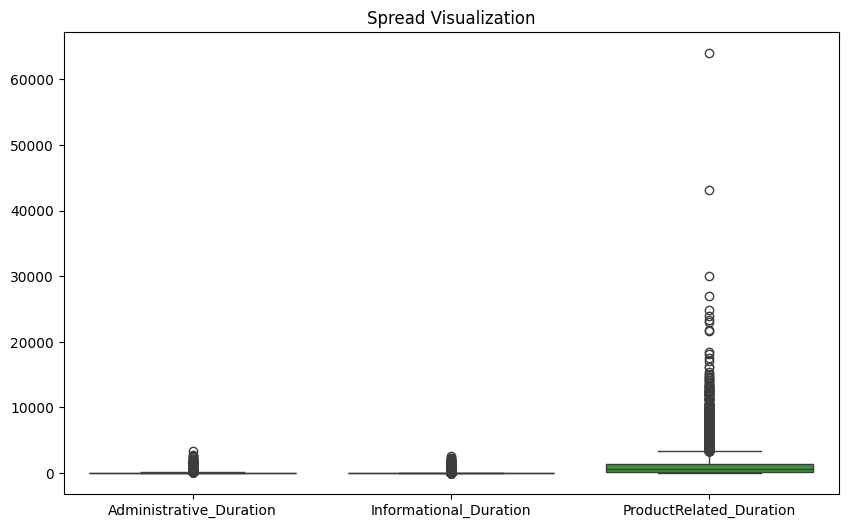

In [ ]:
import seaborn as sns
plt.figure(figsize=(10,6))
sns.boxplot(data = df[['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration']])
plt.title("Spread Visualization")
plt.show()

## Phase 2 — Splitting, outlier analysis, preprocessing

### Train/test split
Stratified 80/20 split (`random_state=42`) to preserve the 15.5% positive-class
ratio in both sets. The test set is held out and used only for the final
evaluation.


In [ ]:
# Stratified 80/20 split: the test set keeps the same positive-class ratio as
# the full dataset, which matters for imbalanced classification
from sklearn.model_selection import train_test_split
from collections import Counter

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
y_train = y_train.values.ravel()
y_test  = y_test.values.ravel()

print(y_train.shape, y_test.shape)
print(Counter(y_train))

(9864,) (2466,)
Counter({np.False_: 8338, np.True_: 1526})


### Outlier analysis (continued)

#### ProductRelated_Duration
Compute the IQR bounds on the training set (we only analyze, we do not filter)
and check the purchase rate of sessions above the upper bound.

In [ ]:
# Compute IQR bounds on the training set
# We use 2.5 * IQR instead of the standard 1.5 * IQR: more conservative,
# fewer rows flagged as outliers
def iqr_bounds(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 2.5 * iqr, q3 + 2.5 * iqr

lower_bound_PD, upper_bound_PD = iqr_bounds(X_train['ProductRelated_Duration'])
lower_bound_AD, upper_bound_AD = iqr_bounds(X_train['Administrative_Duration'])

print('ProductRelated_Duration bounds:', lower_bound_PD, upper_bound_PD)
print('Administrative_Duration bounds:', lower_bound_AD, upper_bound_AD)

ProductRelated_Duration bounds: -3047.289583225 4704.363987875
Administrative_Duration bounds: -232.5 325.5


In [ ]:
# Compare purchase rate in the "outlier" group vs the whole training set
# If outliers have a *higher* conversion rate, they carry signal and should not be removed
mask_outliers_PD = X_train['ProductRelated_Duration'] > upper_bound_PD
purchase_rate_outliers_PD = np.mean(y_train[mask_outliers_PD])
purchase_rate_normal = np.mean(y_train)

print(f"Purchase rate (normal):   {purchase_rate_normal:.2%}")
print(f"Purchase rate (outliers): {purchase_rate_outliers_PD:.2%}")
print(f"Number of outliers:       {mask_outliers_PD.sum()} ({mask_outliers_PD.mean():.2%} of train set)")

Purchase rate (normal):   15.47%
Purchase rate (outliers): 34.34%
Number of outliers:       399 (4.05% of train set)


#### Administrative_Duration
Same procedure as above for Administrative_Duration. Both features show a
*purchase rate above the average* for the "outlier" sessions, which is why we
keep them.

In [ ]:
# Same analysis for Administrative_Duration
mask_AD = (X_train['Administrative_Duration'] >= lower_bound_AD) & \
          (X_train['Administrative_Duration'] <= upper_bound_AD)

removed_rows_AD = len(X_train) - mask_AD.sum()
print(f"Outlier Detection would remove "
      f"{round(removed_rows_AD / len(X_train) * 100, 2)}% of the rows")

mask_outliers = (X_train['Administrative_Duration'] > upper_bound_AD)

purchase_rate_normal = np.mean(y_train)
purchase_rate_outliers = np.mean(y_train[mask_outliers])

print(f"Purchase rate (whole train set)          = "
      f"{round(purchase_rate_normal * 100, 2)}%")
print(f"Purchase rate (Administrative_Duration > {round(upper_bound_AD, 0)}) = "
      f"{round(purchase_rate_outliers * 100, 2)}%")

Outlier Detection would remove 5.59% of the rows
Purchase rate (whole train set)          = 15.47%
Purchase rate (Administrative_Duration > 326.0) = 26.5%


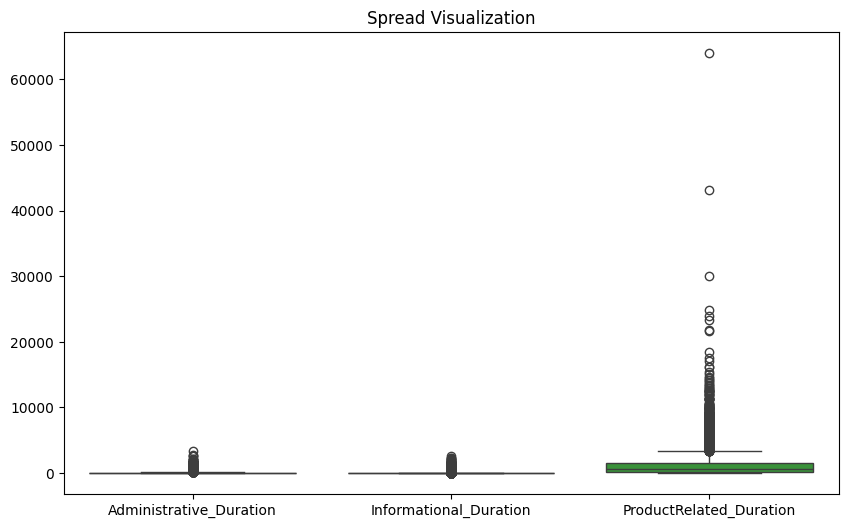

In [ ]:
# Visualize the distribution of the three duration features on the training set after the split
plt.figure(figsize=(10,6))
sns.boxplot(data = X_train[['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration']])
plt.title("Spread Visualization")
plt.show()

### Feature removal
`BounceRates` and `ExitRates` are correlated at r = 0.91 (they measure almost
the same thing). We drop `BounceRates` to reduce multicollinearity, keeping
`ExitRates` as the representative of the pair.




In [ ]:
# We remove BounceRates from the numerical feature list because it is
# almost perfectly correlated with ExitRates (r = 0.91)
numerical_values.remove('BounceRates')

### Preprocessing pipeline
`ColumnTransformer` with One-Hot Encoding for categorical features and
Min-Max scaling for numerical ones. `remainder='drop'` discards any column not
explicitly listed (none in our case). The preprocessor is fit only on the
training set to avoid data leakage.



In [ ]:
# ColumnTransformer: One-Hot for categorical, Min-Max for numerical
# 'remainder=drop' ensures no unexpected column sneaks in
# sparse_output=False keeps the output dense (our feature space is small)
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer


preprocessor = ColumnTransformer(
    transformers=[
        ('onenc',  OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_values),
        ('minmax', MinMaxScaler(),                          numerical_values)
    ],
    remainder='drop'
)


from sklearn.pipeline import Pipeline
preview_pipe = Pipeline([('prep', preprocessor)])
X_preview = preview_pipe.fit_transform(X_train)

if hasattr(X_preview, "toarray"):
    X_preview = X_preview.toarray()
dfTransformed = pd.DataFrame(
    X_preview,
    columns=preview_pipe.named_steps['prep'].get_feature_names_out()
)
dfTransformed.head()

,onenc__Month_Aug,onenc__Month_Dec,onenc__Month_Feb,onenc__Month_Jul,onenc__Month_June,onenc__Month_Mar,onenc__Month_May,onenc__Month_Nov,onenc__Month_Oct,onenc__Month_Sep,...,onenc__Weekend_True,minmax__PageValues,minmax__ExitRates,minmax__Administrative,minmax__Administrative_Duration,minmax__Informational,minmax__Informational_Duration,minmax__ProductRelated,minmax__ProductRelated_Duration,minmax__SpecialDay
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.033929,0.066710,0.296296,0.215447,0.0,0.0,0.048227,0.021036,0.8
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.000000,0.500000,0.000000,0.000000,0.0,0.0,0.005674,0.002457,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.250000,0.000000,0.000000,0.0,0.0,0.005674,0.000657,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.053174,0.187500,0.074074,0.099448,0.0,0.0,0.024113,0.018845,0.8
4,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.151138,0.002933,0.000000,0.000000,0.0,0.0,0.045390,0.012937,0.0


### Baseline CV with SMOTE
5-fold stratified cross-validation of the four base models, with SMOTE applied
inside each fold (via `imblearn.pipeline.Pipeline`). This gives a first estimate
of how each model performs on a balanced training distribution.

In [ ]:
# 5-fold stratified CV of the base models, SMOTE applied inside each fold via imblearn.pipeline.Pipeline. This avoids leaking synthetic samples into the validation folds.
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_validate, StratifiedKFold
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import pandas as pd


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']


base_models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest':       RandomForestClassifier(random_state=42),
    'HistGB':             HistGradientBoostingClassifier(random_state=42),
    'SVM':                SVC(random_state=42),
}


pipelines = {}
for name, clf in base_models.items():
    pipelines[name] = ImbPipeline([
        ('prep',  preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('clf',   clf)
    ])


rows = []
for name, pipe in pipelines.items():
    res = cross_validate(pipe, X_train, y_train,
                         cv=cv, scoring=scoring, n_jobs=-1)
    rows.append({
        'Model':     name,
        'Accuracy':  res['test_accuracy'].mean(),
        'Precision': res['test_precision'].mean(),
        'Recall':    res['test_recall'].mean(),
        'F1':        res['test_f1'].mean(),
        'AUC':       res['test_roc_auc'].mean(),
    })

df_baseline = pd.DataFrame(rows).sort_values('F1', ascending=False)
display(df_baseline)

,Model,Accuracy,Precision,Recall,F1,AUC
1,RandomForest,0.896189,0.649061,0.724768,0.684168,0.920342
2,HistGB,0.898621,0.664556,0.699871,0.681296,0.930301
0,LogisticRegression,0.830902,0.471397,0.749005,0.578517,0.887238
3,SVM,0.835666,0.470897,0.515703,0.492034,0.826959


### SMOTE: preview of class distribution
Quick sanity check: how many samples per class before and after SMOTE. SMOTE is
not applied here to the training set used for final evaluation; it is only
shown to confirm that the pipeline balances the two classes.

In [ ]:
# Show the class distribution before and after SMOTE. Only a preview:
# the actual resampling happens inside the CV pipeline above.
from collections import Counter
from imblearn.over_sampling import SMOTE


print('Original train set:', Counter(y_train))
print('Test set:', Counter(y_test))


sm_preview = SMOTE(random_state=42)
X_preview_res, y_preview_res = sm_preview.fit_resample(X_preview, y_train)
print('After SMOTE (preview, NOT used for training):', Counter(y_preview_res))

Original train set: Counter({np.False_: 8338, np.True_: 1526})
Test set: Counter({np.False_: 2084, np.True_: 382})
After SMOTE (preview, NOT used for training): Counter({np.False_: 8338, np.True_: 8338})


In [ ]:


print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (2466, 17)
y_test shape: (2466,)


## Phase 3 — Trivial benchmark

### Benchmark: always predict "No purchase"
A trivial classifier that predicts the majority class reaches 84.5% accuracy but
zero F1 on the positive class. This confirms that accuracy alone is misleading
on this dataset, and justifies using F1/AUC as primary metrics.

In [ ]:
# Trivial benchmark: always predict "No"
# Accuracy ~84.5%, F1 = 0
# This is the baseline any meaningful model must beat
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred_dummy = [False] * len(y_test)
print(f"Acc={accuracy_score(y_test, y_pred_dummy):.3f}  "
      f"Prec={precision_score(y_test, y_pred_dummy, zero_division=0):.3f}  "
      f"Rec={recall_score(y_test, y_pred_dummy, zero_division=0):.3f}  "
      f"F1={f1_score(y_test, y_pred_dummy, zero_division=0):.3f}")

Acc=0.845  Prec=0.000  Rec=0.000  F1=0.000


## Phase 4 — Hyperparameter tuning and final evaluation

In [ ]:
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
preview_pipe = Pipeline([('prep', preprocessor)])

dfTransformed = pd.DataFrame(
    X_preview,
    columns=preview_pipe.named_steps['prep'].get_feature_names_out()
)
dfTransformed.head()

,onenc__Month_Aug,onenc__Month_Dec,onenc__Month_Feb,onenc__Month_Jul,onenc__Month_June,onenc__Month_Mar,onenc__Month_May,onenc__Month_Nov,onenc__Month_Oct,onenc__Month_Sep,...,onenc__Weekend_True,minmax__PageValues,minmax__ExitRates,minmax__Administrative,minmax__Administrative_Duration,minmax__Informational,minmax__Informational_Duration,minmax__ProductRelated,minmax__ProductRelated_Duration,minmax__SpecialDay
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.033929,0.066710,0.296296,0.215447,0.0,0.0,0.048227,0.021036,0.8
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.000000,0.500000,0.000000,0.000000,0.0,0.0,0.005674,0.002457,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.250000,0.000000,0.000000,0.0,0.0,0.005674,0.000657,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.053174,0.187500,0.074074,0.099448,0.0,0.0,0.024113,0.018845,0.8
4,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.151138,0.002933,0.000000,0.000000,0.0,0.0,0.045390,0.012937,0.0


### Grid search with SMOTE
GridSearchCV (5-fold, scoring='f1') for each model, with SMOTE applied inside
each fold. The best configuration is selected on the validation F1 and then
evaluated once on the held-out test set.

In [ ]:
# GridSearchCV over the SMOTE-augmented pipeline. Scoring = F1 on the positive class, since the classes are imbalanced and accuracy is misleading.
from sklearn.model_selection import GridSearchCV
import time
start = time.time()
param_grid_rf = {
    'clf__n_estimators':     [100, 200],
    'clf__max_depth':        [10, None],
    'clf__min_samples_leaf': [1, 4],
    }


gs_rf = GridSearchCV(
    ImbPipeline([
        ('prep',  preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('clf',   RandomForestClassifier(random_state=42, n_jobs=-1))
    ]),
    param_grid_rf, cv=cv, scoring='f1', n_jobs=1, verbose=2
)
gs_rf.fit(X_train, y_train)
print("RF best:", gs_rf.best_params_, "F1 =", round(gs_rf.best_score_, 4))
print(f"RF grid search time: {(time.time()-start)/60:.1f} min")


Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END clf__max_depth=10, clf__min_samples_leaf=1, clf__n_estimators=100; total time=   2.4s
[CV] END clf__max_depth=10, clf__min_samples_leaf=1, clf__n_estimators=100; total time=   1.4s
[CV] END clf__max_depth=10, clf__min_samples_leaf=1, clf__n_estimators=100; total time=   1.5s
[CV] END clf__max_depth=10, clf__min_samples_leaf=1, clf__n_estimators=100; total time=   1.5s
[CV] END clf__max_depth=10, clf__min_samples_leaf=1, clf__n_estimators=100; total time=   1.4s
[CV] END clf__max_depth=10, clf__min_samples_leaf=1, clf__n_estimators=200; total time=   2.9s
[CV] END clf__max_depth=10, clf__min_samples_leaf=1, clf__n_estimators=200; total time=   4.4s
[CV] END clf__max_depth=10, clf__min_samples_leaf=1, clf__n_estimators=200; total time=   4.7s
[CV] END clf__max_depth=10, clf__min_samples_leaf=1, clf__n_estimators=200; total time=   2.8s
[CV] END clf__max_depth=10, clf__min_samples_leaf=1, clf__n_estimators=200; total tim

In [ ]:
from sklearn.model_selection import GridSearchCV
import time
start = time.time()

param_grid_gb = {
    'clf__max_iter':      [100, 200],
    'clf__learning_rate': [0.05, 0.1],
    'clf__max_depth':     [3, None],
}


gs_gb = GridSearchCV(
    ImbPipeline([
        ('prep',  preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('clf',   HistGradientBoostingClassifier(random_state=42))
    ]),
    param_grid_gb, cv=cv, scoring='f1', n_jobs=-1, verbose=2
)
gs_gb.fit(X_train, y_train)
print("GB best:", gs_gb.best_params_, "F1 =", round(gs_gb.best_score_, 4))
print(f"GB grid search Time: {(time.time()-start)/60:.1f} min")


Fitting 5 folds for each of 8 candidates, totalling 40 fits
GB best: {'clf__learning_rate': 0.05, 'clf__max_depth': None, 'clf__max_iter': 100} F1 = 0.6954
GB grid search Time: 1.1 min


In [ ]:
start = time.time()
param_grid_lr = {
    'clf__C':       [0.01, 0.1, 1, 10],
    'clf__penalty': ['l2'],
    'clf__solver':  ['lbfgs'],
}
gs_lr = GridSearchCV(
    ImbPipeline([
        ('prep',  preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('clf',   LogisticRegression(max_iter=1000, random_state=42))
    ]),
    param_grid_lr, cv=cv, scoring='f1', n_jobs=-1, verbose=2
)
gs_lr.fit(X_train, y_train)
print("LR best:", gs_lr.best_params_, "F1 =", round(gs_lr.best_score_, 4))
print(f"LR grid search Time: {(time.time()-start)/60:.1f} min")

Fitting 5 folds for each of 4 candidates, totalling 20 fits
LR best: {'clf__C': 10, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'} F1 = 0.6193
LR grid search Time: 0.1 min


In [ ]:
start = time.time()
param_grid_svm = {
    'clf__C':      [1, 10],
    'clf__kernel': ['rbf'],
    'clf__gamma':  ['scale'],
}
gs_svm = GridSearchCV(
    ImbPipeline([
        ('prep',  preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('clf',   SVC(random_state=42, probability=False))
    ]),
    param_grid_svm, cv=cv, scoring='f1', n_jobs=-1, verbose=2
)
gs_svm.fit(X_train, y_train)
print("SVM best:", gs_svm.best_params_, "F1 =", round(gs_svm.best_score_, 4))
print(f"SVM grid search Time: {(time.time()-start)/60:.1f} min")


Fitting 5 folds for each of 2 candidates, totalling 10 fits
SVM best: {'clf__C': 10, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'} F1 = 0.5398
SVM grid search Time: 1.6 min


### Final evaluation on the test set
Test-set performance of the best configuration for each model, plus the
confusion matrices. The test set has never been used during tuning.

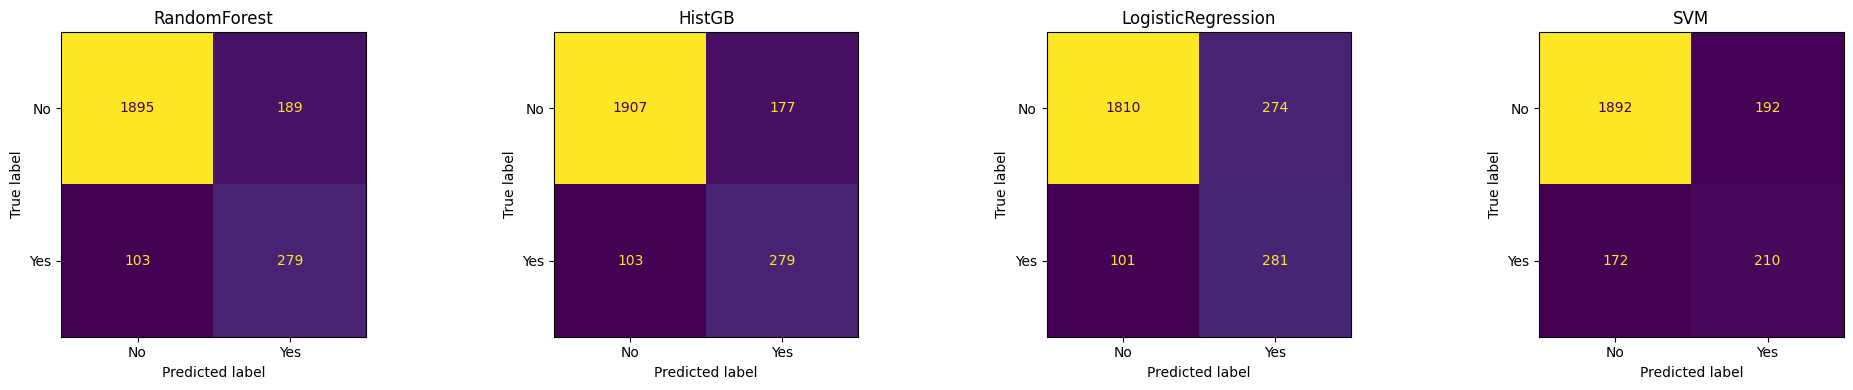

,Model,Accuracy,Precision,Recall,F1,AUC
1,HistGB,0.886456,0.611842,0.730366,0.665871,0.929370
0,RandomForest,0.881590,0.596154,0.730366,0.656471,0.916066
2,LogisticRegression,0.847932,0.506306,0.735602,0.599787,0.888801
3,SVM,0.852393,0.522388,0.549738,0.535714,0.822682


In [ ]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score)
import matplotlib.pyplot as plt

best_models = {
    'RandomForest':       gs_rf.best_estimator_,
    'HistGB':             gs_gb.best_estimator_,
    'LogisticRegression': gs_lr.best_estimator_,
    'SVM':                gs_svm.best_estimator_,
}

final_rows = []
fig, axes = plt.subplots(1, len(best_models), figsize=(20, 4))

for ax, (name, model) in zip(axes, best_models.items()):
    y_pred = model.predict(X_test)

    report = classification_report(y_test, y_pred, output_dict=True)
    final_rows.append({
        'Model':     name,
        'Accuracy':  report['accuracy'],
        'Precision': report['True']['precision'],
        'Recall':    report['True']['recall'],
        'F1':        report['True']['f1-score'],
        'AUC':       roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
                     if hasattr(model, 'predict_proba')
                     else roc_auc_score(y_test, model.decision_function(X_test))
    })

    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['No','Yes']).plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

df_final = pd.DataFrame(final_rows).sort_values('F1', ascending=False)
display(df_final)

### Sanity check
Confirm that the maximum of `ProductRelated_Duration` is the same in the full
dataframe and in the training set, i.e. that no outlier filtering was applied.

In [ ]:
# Sanity check: the maximum of ProductRelated_Duration is identical in df and
# X_train, confirming no outlier filtering was applied to the training data
print("Max ProductRelated_Duration in X_train:", X_train['ProductRelated_Duration'].max())
print("Max ProductRelated_Duration in X_test: ", X_test['ProductRelated_Duration'].max())
print("Max ProductRelated_Duration in df:     ", df['ProductRelated_Duration'].max())

Max ProductRelated_Duration in X_train: 63973.52223
Max ProductRelated_Duration in X_test:  27009.85943
Max ProductRelated_Duration in df:      63973.52223
